In [50]:
import kagglehub
import numpy as np
import pandas as pd
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm

In [51]:
#get data from kaggle
path = kagglehub.dataset_download("zhangluyuan/ab-testing")
df = pd.read_csv(Path(path) / "ab_data.csv")

df.head()


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [52]:
#find out if type conversions are necessary
#look at initial memory usage
df.info(memory_usage = "deep")

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 57.6 MB


In [53]:
#find out if downcasting integers is viable
df.describe() 

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


DATA CLEANING:

#Casting: 

- 'user_id' column can be downcast to an int32
- 'timestamp' column needs to be converted to an actual timestamp
- 'group' and 'landing_page' columns can be converted to categories
- 'converted' column could be converted to a boolean

#Further info obtained from data wrangler:

- no null or erroneous values in any column
- many repeated user_id's (~1%) - find out if it's okay to keep them

In [54]:
df['user_id'] = df['user_id'].astype('int32')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['group'] = df['group'].astype('category')
df['landing_page'] = df['landing_page'].astype('category')
df['converted'] = df['converted'].astype('bool')

df.info(memory_usage='deep') #memory reduced from 57.6MB to 4.2MB

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int32         
 1   timestamp     294478 non-null  datetime64[us]
 2   group         294478 non-null  category      
 3   landing_page  294478 non-null  category      
 4   converted     294478 non-null  bool          
dtypes: bool(1), category(2), datetime64[us](1), int32(1)
memory usage: 4.2 MB


In [55]:
dupl = duckdb.sql(
"""
--Remove rows where the the landing page does not correspond to the correct group

WITH valid_group AS(
SELECT * FROM df WHERE ("group" = 'treatment' AND landing_page = 'new_page') OR ("group" = 'control' AND landing_page = 'old_page')
)

--Any remaining duplicate rows will have the same group and landing page, so just keep the one with the earlier timestamp

SELECT * EXCLUDE(rn) FROM(SELECT *, ROW_NUMBER() OVER(partition by user_id ORDER BY timestamp) AS rn FROM valid_group) WHERE rn = 1
"""
).df()

dupl

,user_id,timestamp,group,landing_page,converted
0,688164,2017-01-17 03:08:34.222685,treatment,new_page,False
1,916243,2017-01-23 04:51:49.923826,control,old_page,False
2,741948,2017-01-21 23:50:05.588557,treatment,new_page,True
3,862502,2017-01-11 11:17:20.175366,treatment,new_page,False
4,876534,2017-01-07 11:50:47.956945,treatment,new_page,False
...,...,...,...,...,...
290579,710727,2017-01-14 09:55:14.392767,treatment,new_page,False
290580,677860,2017-01-13 15:20:20.921697,treatment,new_page,False
290581,921008,2017-01-10 19:11:03.749130,treatment,new_page,False
290582,747348,2017-01-23 11:56:08.098582,treatment,new_page,False


In [56]:
control = df[(df["group"] == "control")]
treatment = df[(df["group"] == "treatment")]

control_conversions = control["converted"].sum()
treatment_conversions = treatment["converted"].sum()

control_conversion_rate = control_conversions / len(control)
treatment_conversion_rate = treatment_conversions / len(treatment)

print(control_conversion_rate)
print(treatment_conversion_rate)

0.12039917935897611
0.11891957956489856


In [57]:
#create dictionary for results and convert to dataframe

stats = pd.DataFrame({
    "Group" : ["Control", "Treatment"],
    "No. Users" : [len(control), len(treatment)],
    "No. Conversions" : [control_conversions, treatment_conversions],
    "Conversion Rate" : [control_conversion_rate, treatment_conversion_rate]
})

stats


,Group,No. Users,No. Conversions,Conversion Rate
0,Control,147202,17723,0.120399
1,Treatment,147276,17514,0.118920


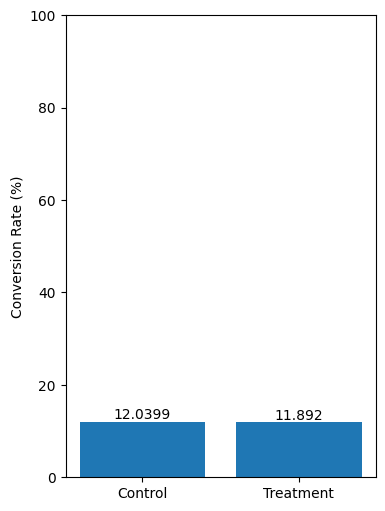

In [58]:
#demosntrate conversion rates in a bar chart

plt.figure(figsize=(4,6))
bar_chart = plt.bar(
    x = ["Control", "Treatment"],
    height = [control_conversion_rate * 100, treatment_conversion_rate * 100] 
)
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.bar_label(bar_chart)
plt.show()


# A/B Test: Two-Proportion Z-Test

## Problem

Let

- $p_C$ = true conversion proportion in the control group
- $p_T$ = true conversion proportion in the treatment group

We wish to determine whether the treatment group has a higher conversion rate than the control group.

### Hypotheses

$$
H_0 : p_T = p_C
$$

equivalently,

$$
H_0 : p_T - p_C = 0
$$

versus

$$
H_1 : p_T > p_C
$$

equivalently,

$$
H_1 : p_T - p_C > 0
$$

We choose a significance level of

$$
\alpha = 0.05.
$$

In [59]:
#re-assign variables to be used in a mathematical context

n_t = len(treatment)
x_t = treatment_conversions

n_c = len(control)
x_c = control_conversions

p_hat_t = treatment_conversion_rate
p_hat_c = control_conversion_rate

#re-affirm output
print(f"Treatment conversion rate = {p_hat_t:.6f}")
print(f"Control conversion rate   = {p_hat_c:.6f}")
print(f"Difference                = {p_hat_t - p_hat_c:.6f}")

Treatment conversion rate = 0.118920
Control conversion rate   = 0.120399
Difference                = -0.001480


## Estimators

The population proportions $p_T$ and $p_C$ are unknown.

We estimate them using the sample proportions

$$
\hat p_T = \frac{x_T}{n_T}
$$

and

$$
\hat p_C = \frac{x_C}{n_C}.
$$

These estimators are unbiased because

$$
E[\hat p_T] = p_T
$$

and

$$
E[\hat p_C] = p_C.
$$

Therefore the estimator

$$
\hat p_T - \hat p_C
$$

is also unbiased for

$$
p_T - p_C.
$$

## Test Construction

To perform the hypothesis test, assume the null hypothesis is true.

Under

$$
H_0 : p_T = p_C = p,
$$

both groups share a common population proportion $p$.

Since $p$ is unknown, we estimate it using the pooled proportion

$$
\hat p
=
\frac{x_T+x_C}{n_T+n_C}.
$$

In [60]:
p_pool = (x_t + x_c) / (n_t + n_c)

print(f"Pooled proportion = {p_pool:.9f}")

Pooled proportion = 0.119659194


For these data,

$$
\hat p
=
\frac{17723+17514}
{147202+147276}
=
0.119659.
$$

## Standard Error

Under the null hypothesis, the sampling distribution of

$$
\hat p_T-\hat p_C
$$

has variance

$$
\operatorname{Var}(\hat p_T-\hat p_C)
=
p(1-p)
\left(
\frac1{n_T}
+
\frac1{n_C}
\right).
$$

Replacing $p$ with the pooled estimate gives the estimated standard error

$$
SE
=
\sqrt{
\hat p(1-\hat p)
\left(
\frac1{n_T}
+
\frac1{n_C}
\right)
}.
$$

In [61]:
se_pooled = np.sqrt(
    p_pool*(1-p_pool)*(1/n_t + 1/n_c)
)

print(f"SE = {se_pooled:.6f}")

SE = 0.001196


This standard error measures the typical variation of

$$
\hat p_T-\hat p_C
$$

that we would expect if the null hypothesis were true.